<a href="https://colab.research.google.com/github/dreayrt/THDeepLearning/blob/Buoi3/ThucHanhBuoi3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8260 - loss: 0.4910 - val_accuracy: 0.8543 - val_loss: 0.4057
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8665 - loss: 0.3665 - val_accuracy: 0.8657 - val_loss: 0.3664
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8791 - loss: 0.3276 - val_accuracy: 0.8713 - val_loss: 0.3530
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8892 - loss: 0.3024 - val_accuracy: 0.8730 - val_loss: 0.3518
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8949 - loss: 0.2847 - val_accuracy: 0.8805 - val_loss: 0.3262
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9001 - loss: 0.2707 - val_accuracy: 0.8885 - val_loss: 0.3130
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9044 - loss: 0.2581 - val_accuracy: 0.8863 - val_loss: 0.3243
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9076 - loss: 0.24

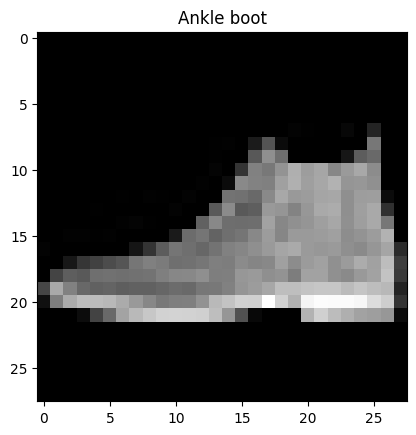

In [ ]:
#BÀI TẬP MẪU
!pip uninstall -y jax jaxlib
!pip install tensorflow==2.15.0
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
# Load dataset Fashion MNIST
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
# Reshape dữ liệu từ 28x28 -> 784
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
# Chuẩn hóa dữ liệu
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Xây dựng ANN model
model = Sequential()
# Hidden layer
model.add(Dense(
    units=256,
    input_dim=784,
    activation='relu'
))
# Output layer
model.add(Dense(
    units=10,
    activation='softmax'
))
# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)
# Đánh giá model
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)
# Nhãn Fashion MNIST
labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}
# Dự đoán ảnh test đầu tiên
predict = model.predict(X_test)
index = 0
label = np.argmax(predict[index])
print("Predict:", labels[label])
print("True:", labels[y_test[index]])
# Hiển thị ảnh
plt.imshow(X_test[index].reshape(28,28), cmap='gray')
plt.title(labels[label])
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


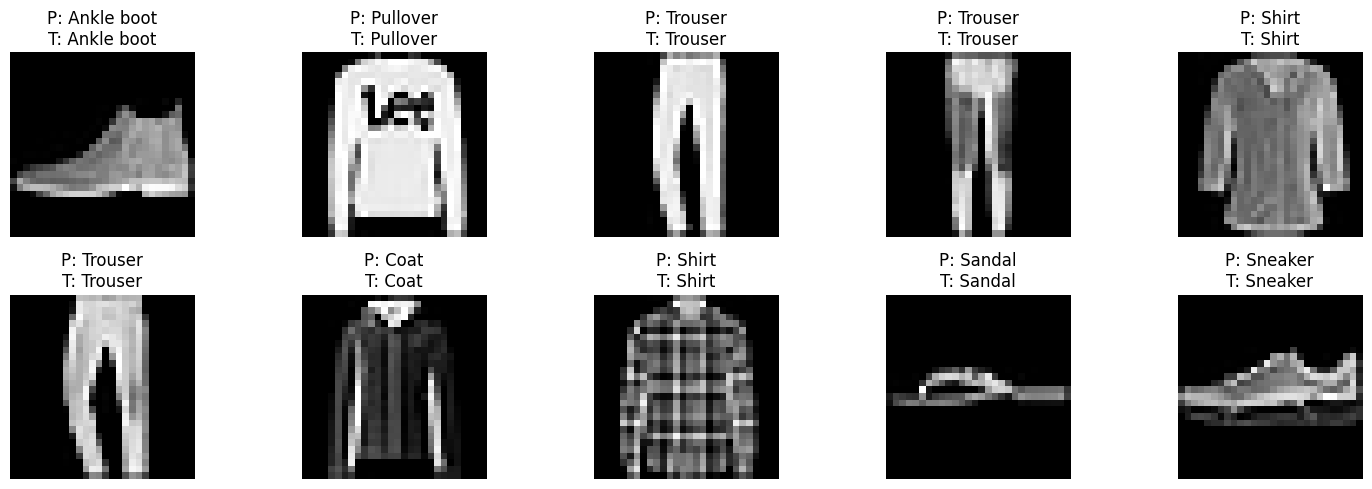

In [ ]:
predict = model.predict(X_test)
labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}
# Hiển thị 10 ảnh đầu tiên
plt.figure(figsize=(15,5))
for i in range(10):
    predicted_label = np.argmax(predict[i])
    true_label = y_test[i]
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(
        f"P: {labels[predicted_label]}\nT: {labels[true_label]}"
    )
    plt.axis('off')
plt.tight_layout()
plt.show()

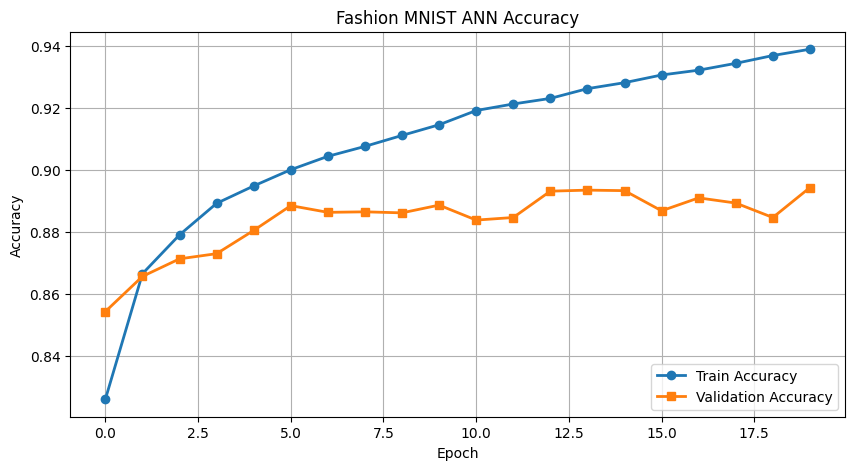

In [ ]:
# ===== Plot Accuracy =====
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    marker='o',
    linewidth=2,
    label='Train Accuracy'
)
plt.plot(
    history.history['val_accuracy'],
    marker='s',
    linewidth=2,
    label='Validation Accuracy'
)
plt.title('Fashion MNIST ANN Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.grid(True)
plt.legend(loc='lower right')
plt.savefig('fashion_mnist_accuracy.png')
plt.show()

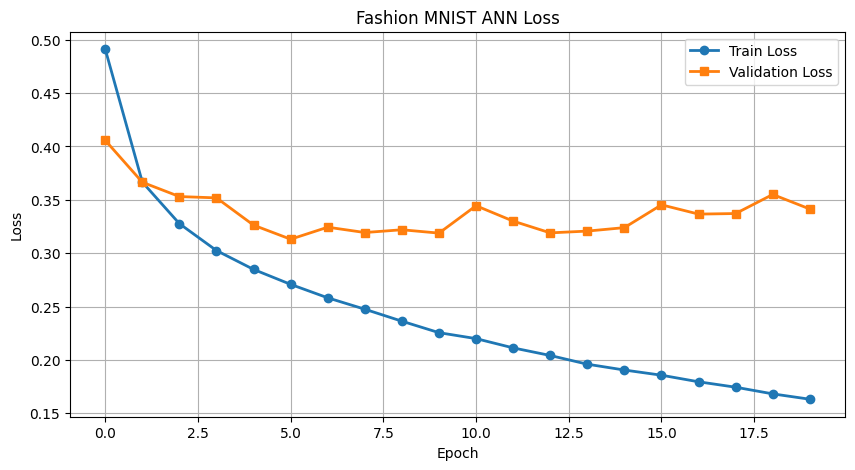

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(
    history.history['loss'],
    marker='o',
    linewidth=2,
    label='Train Loss'
)
plt.plot(
    history.history['val_loss'],
    marker='s',
    linewidth=2,
    label='Validation Loss'
)
plt.title('Fashion MNIST ANN Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.grid(True)
plt.legend(loc='upper right')
plt.savefig('fashion_mnist_loss.png')
plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 74s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


/tmp/ipykernel_831/1697899723.py:57: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(labels[int(y_train[i])])


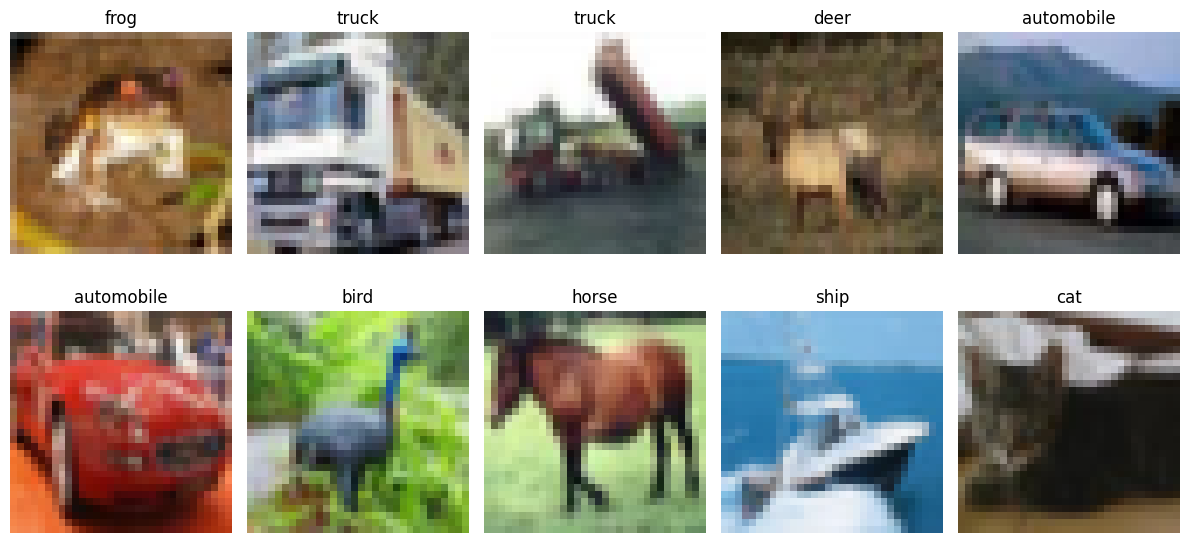

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.2487 - loss: 2.0318 - val_accuracy: 0.3128 - val_loss: 1.8984
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3028 - loss: 1.9010 - val_accuracy: 0.3206 - val_loss: 1.8510
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3156 - loss: 1.8560 - val_accuracy: 0.3494 - val_loss: 1.7898
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3338 - loss: 1.8249 - val_accuracy: 0.3618 - val_loss: 1.7634
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.3407 - loss: 1.8002 - val_accuracy: 0.3686 - val_loss: 1.7706
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.3484 - loss: 1.7822 - val_accuracy: 0.3818 - val_loss: 1.7560
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3500 - loss: 1.7732 - val_accuracy: 0.4024 - val_loss: 1.7024
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3603 - loss: 1.7555 - 

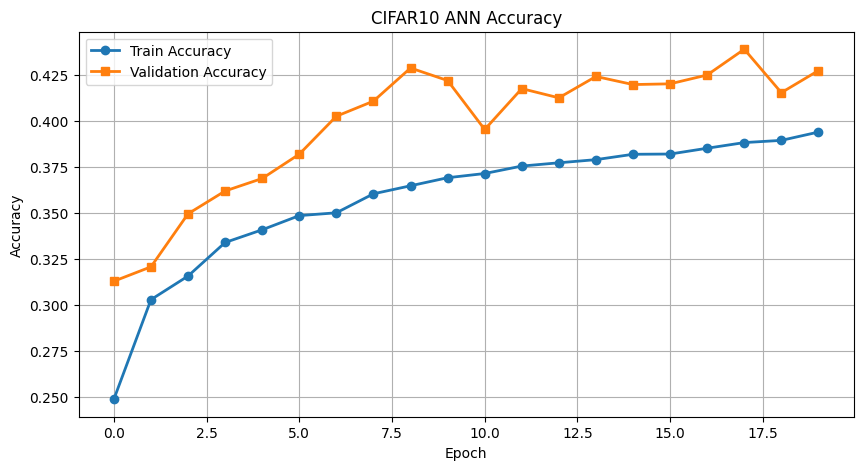

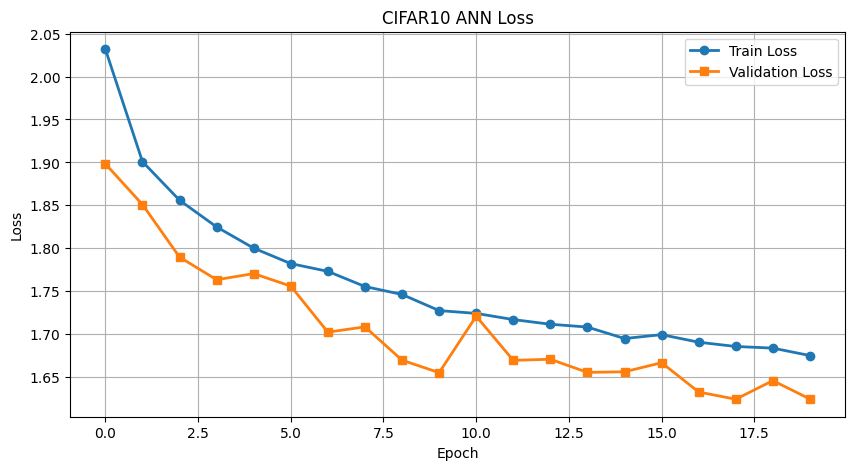

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


/tmp/ipykernel_831/1697899723.py:169: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = int(y_test[i])


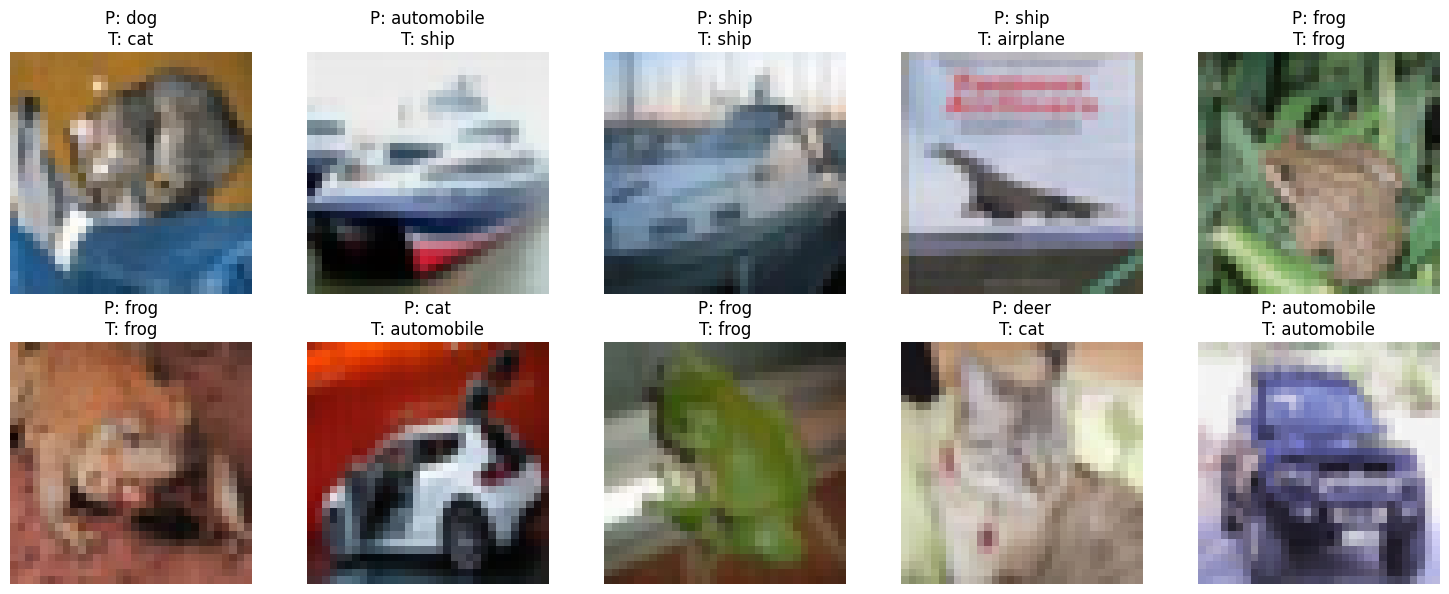

In [ ]:
#BÀI TẬP 1
# ==========================================
# CIFAR10 IMAGE CLASSIFICATION USING ANN
# ==========================================

# ===== Import Libraries =====
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# ===== Load CIFAR10 Dataset =====
cifar10 = tf.keras.datasets.cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ===== Reshape Data =====
# 32x32x3 -> 3072
X_train = X_train.reshape(50000, 3072)
X_test = X_test.reshape(10000, 3072)

# ===== Normalize Data =====
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===== CIFAR10 Labels =====
labels = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck"
}

# ===== Visualize Dataset =====
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i].reshape(32,32,3))

    plt.title(labels[int(y_train[i])])

    plt.axis('off')

plt.tight_layout()
plt.show()

# ===== Build ANN Model =====
model = Sequential()

# Hidden Layer 1
model.add(Dense(
    units=512,
    input_dim=3072,
    activation='relu'
))

model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(
    units=256,
    activation='relu'
))

model.add(Dropout(0.3))

# Hidden Layer 3
model.add(Dense(
    units=128,
    activation='relu'
))

# Output Layer
model.add(Dense(
    units=10,
    activation='softmax'
))

#Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Model Summary
model.summary()

#Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)
#Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)
#Plot Accuracy
plt.figure(figsize=(10,5))
plt.plot(
    history.history['accuracy'],
    marker='o',
    linewidth=2,
    label='Train Accuracy'
)
plt.plot(
    history.history['val_accuracy'],
    marker='s',
    linewidth=2,
    label='Validation Accuracy'
)
plt.title('CIFAR10 ANN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.savefig('cifar10_accuracy.png')
plt.show()
#Plot Loss
plt.figure(figsize=(10,5))
plt.plot(
    history.history['loss'],
    marker='o',
    linewidth=2,
    label='Train Loss'
)
plt.plot(
    history.history['val_loss'],
    marker='s',
    linewidth=2,
    label='Validation Loss'
)
plt.title('CIFAR10 ANN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.savefig('cifar10_loss.png')
plt.show()
#Predict Multiple Images
predict = model.predict(X_test)

plt.figure(figsize=(15,6))

for i in range(10):

    predicted_label = np.argmax(predict[i])

    true_label = int(y_test[i])

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i].reshape(32,32,3))

    plt.title(
        f"P: {labels[predicted_label]}\nT: {labels[true_label]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig('cifar10_predictions.png')

plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


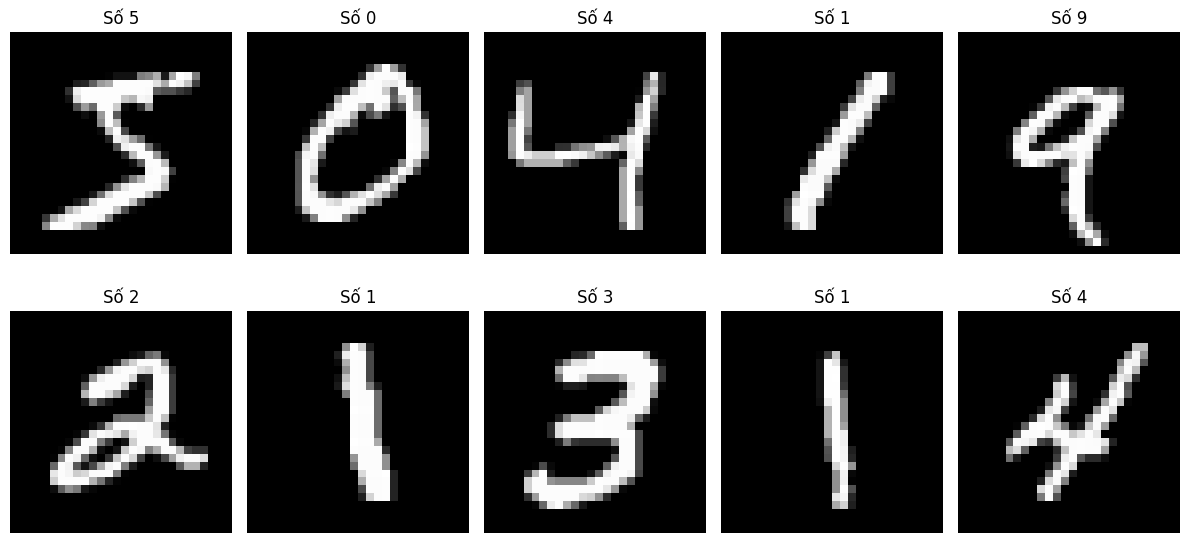

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9258 - loss: 0.2459 - val_accuracy: 0.9697 - val_loss: 0.0967
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9636 - loss: 0.1166 - val_accuracy: 0.9765 - val_loss: 0.0748
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9731 - loss: 0.0845 - val_accuracy: 0.9782 - val_loss: 0.0743
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9784 - loss: 0.0696 - val_accuracy: 0.9777 - val_loss: 0.0727
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9805 - loss: 0.0598 - val_accuracy: 0.9782 - val_loss: 0.0698
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9825 - loss: 0.0515 - val_accuracy: 0.9808 - val_loss: 0.0674
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9847 - loss: 0.0473 - val_accuracy: 0.9823 - val_loss: 0.0646
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9859 - loss: 0

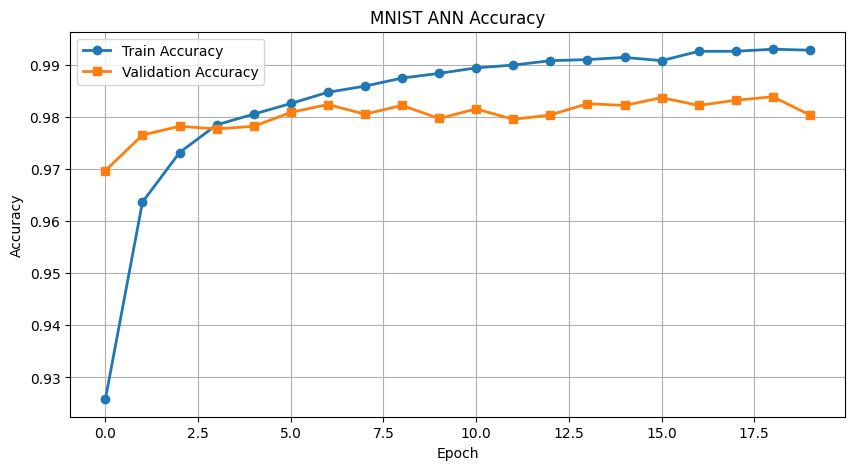

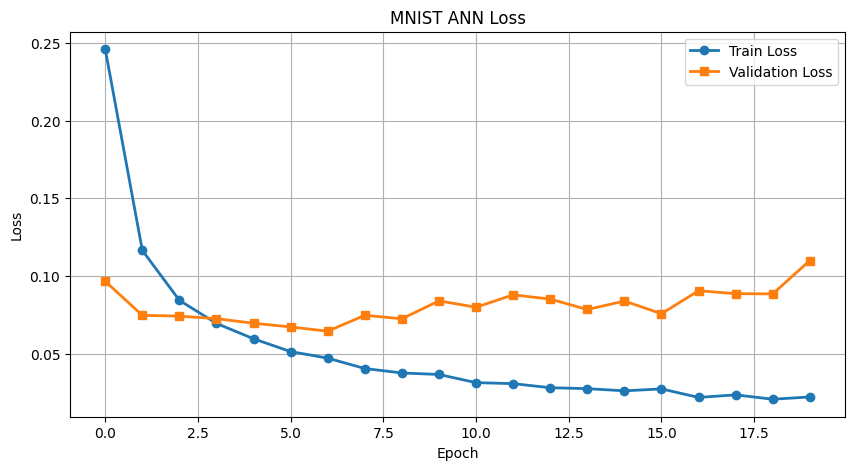

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


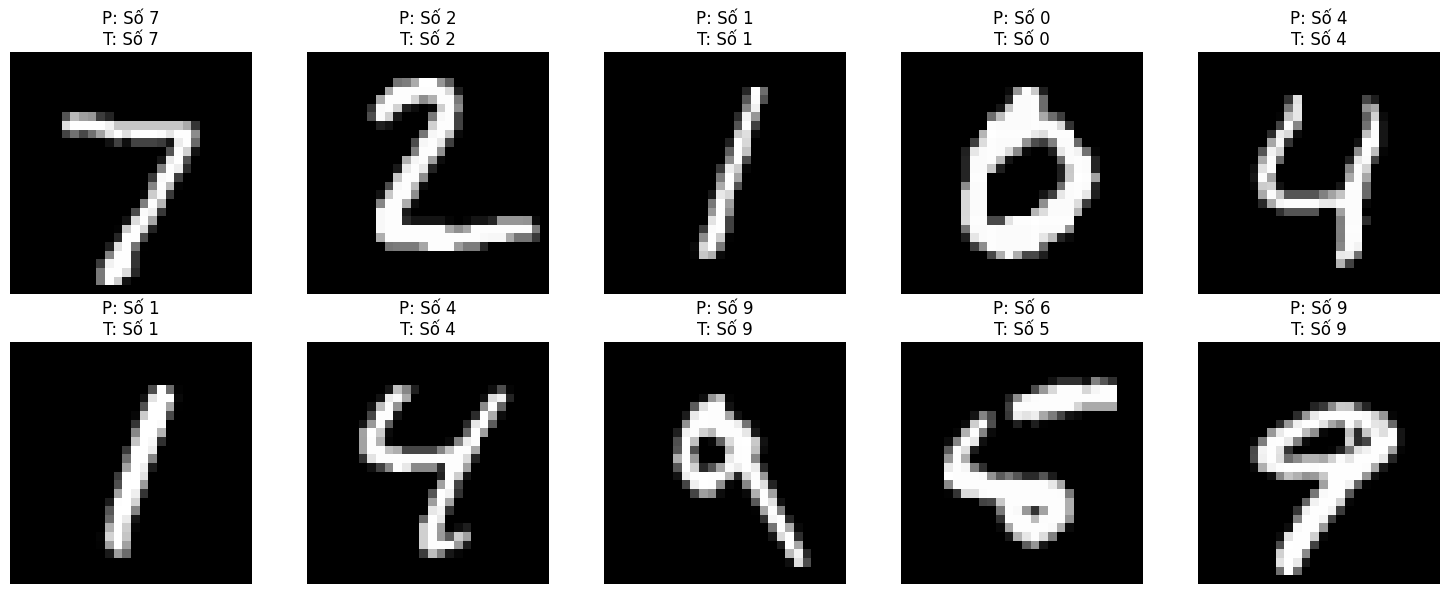

In [ ]:
#BÀI TẬP @

#Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

#Load MNIST Dataset
mnist = tf.keras.datasets.mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

#Reshape Data
# 28x28 -> 784
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

#Normalize Data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#Labels
labels = {
    0: "Số 0",
    1: "Số 1",
    2: "Số 2",
    3: "Số 3",
    4: "Số 4",
    5: "Số 5",
    6: "Số 6",
    7: "Số 7",
    8: "Số 8",
    9: "Số 9"
}

#Visualize Dataset
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i].reshape(28,28), cmap='gray')

    plt.title(labels[y_train[i]])

    plt.axis('off')

plt.tight_layout()
plt.show()

#Build ANN Model
model = Sequential()

#Hidden Layer 1
model.add(Dense(
    units=256,
    input_dim=784,
    activation='relu'
))

model.add(Dropout(0.2))
#Hidden Layer 2
model.add(Dense(
    units=128,
    activation='relu'
))
#Output Layer
model.add(Dense(
    units=10,
    activation='softmax'
))
#Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
#Model Summary
model.summary()
#Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

#Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

#Plot Accuracy
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    marker='o',
    linewidth=2,
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    marker='s',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title('MNIST ANN Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.grid(True)

plt.legend()

plt.savefig('mnist_accuracy.png')

plt.show()

#Plot Loss
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    marker='o',
    linewidth=2,
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    marker='s',
    linewidth=2,
    label='Validation Loss'
)

plt.title('MNIST ANN Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.grid(True)

plt.legend()

plt.savefig('mnist_loss.png')

plt.show()

#Predict Multiple Images
predict = model.predict(X_test)
plt.figure(figsize=(15,6))
for i in range(10):
    predicted_label = np.argmax(predict[i])
    true_label = y_test[i]
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(
        f"P: {labels[predicted_label]}\nT: {labels[true_label]}"
    )
    plt.axis('off')
plt.tight_layout()
plt.savefig('mnist_predictions.png')
plt.show()